<>:56: SyntaxWarning: invalid escape sequence '\s'
<>:56: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2262/2510083122.py:56: SyntaxWarning: invalid escape sequence '\s'
  plt.legend(); plt.title("Ejercicio 2: $-U'' = \sin(\pi x)$")


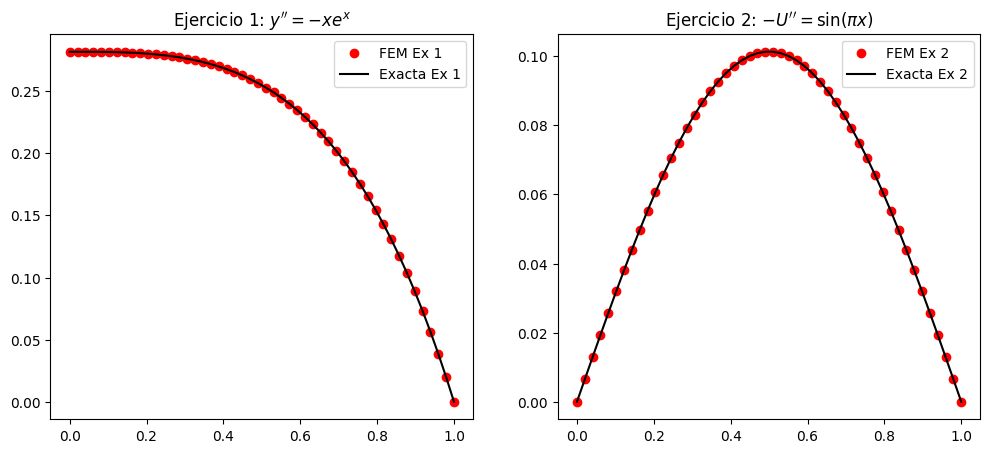

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

def solve_fem(f, a, b, N, ya, yb):
    x = np.linspace(a, b, N)
    h = (b - a) / (N - 1)

    #Ensamblaje Matriz de Rigidez (Global)
    A = np.zeros((N, N))
    for i in range(N - 1):
        # Matriz elemental (1/h * [1, -1; -1, 1])
        A[i, i]     += 1/h
        A[i, i+1]   += -1/h
        A[i+1, i]   += -1/h
        A[i+1, i+1] += 1/h

    #Vector de Carga (Global)
    vec_b = np.zeros(N)
    for i in range(N - 1):
        # Integración local usando funciones de forma lineales
        phi1 = lambda xi: (x[i+1] - xi) / h
        phi2 = lambda xi: (xi - x[i]) / h

        vec_b[i]   += quad(lambda xi: f(xi) * phi1(xi), x[i], x[i+1])[0]
        vec_b[i+1] += quad(lambda xi: f(xi) * phi2(xi), x[i], x[i+1])[0]

    # Aplicar Condiciones de Contorno (Dirichlet)
    # Fila 0 para y(0) = ya
    A[0, :] = 0; A[0, 0] = 1; vec_b[0] = ya
    # Fila N-1 para y(L) = yb
    A[N-1, :] = 0; A[N-1, N-1] = 1; vec_b[N-1] = yb

    return x, np.linalg.solve(A, vec_b)

#  EJERCICIO 1
f1 = lambda x: x * np.exp(x)
x1, y1 = solve_fem(f1, 0, 1, 50, (3 - np.exp(1)), 0)
y_exact1 = 1 - np.exp(1) - np.exp(x1)*(x1 - 2) - x1

#  EJERCICIO 2
f2 = lambda x: np.sin(np.pi * x)
x2, y2 = solve_fem(f2, 0, 1, 50, 0, 0)
y_exact2 = np.sin(np.pi * x2) / (np.pi**2)

# GRAFICACIÓN
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(x1, y1, 'ro', label='FEM Ex 1')
plt.plot(x1, y_exact1, 'k-', label='Exacta Ex 1')
plt.legend(); plt.title("Ejercicio 1: $y'' = -xe^x$")

plt.subplot(1, 2, 2)
plt.plot(x2, y2, 'ro', label='FEM Ex 2')
plt.plot(x2, y_exact2, 'k-', label='Exacta Ex 2')
plt.legend(); plt.title("Ejercicio 2: $-U'' = \sin(\pi x)$")
plt.show()

Nota 4.0 Revisado... Entrega tarde. Quizás mal el git push!